In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional
from scipy import stats

# Plot settings
plt.style.use("ggplot")
sns.set_palette("Set2")
pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("../data/MachineLearningRating_v3.txt", sep='|')

In [ ]:
df.head()
df.shape

In [ ]:
df.columns

Initial Dataset Inspection

In [ ]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Data types
display(df.info())

# Preview rows
display(df.head())

# Statistical summary
display(df.describe().T)

Convert Date Columns

In [ ]:
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])

df['VehicleIntroDate'] = pd.to_datetime(
    df['VehicleIntroDate'],
    errors='coerce'
)

In [ ]:
df[['TransactionMonth', 'VehicleIntroDate']].head()


Create Insurance Business Metrics

In [16]:
import numpy as np

df['LossRatio'] = np.where(
    df['TotalPremium'] == 0,
    np.nan,
    df['TotalClaims'] / df['TotalPremium']
)

In [17]:
df['Margin'] = (
    df['TotalPremium'] - df['TotalClaims']
)

Missing Values Assessment

In [18]:
missing = pd.DataFrame({
    'MissingValues': df.isnull().sum(),
    'Percentage': (
        df.isnull().sum() / len(df)
    ) * 100
})

missing = missing[
    missing['MissingValues'] > 0
].sort_values(
    by='Percentage',
    ascending=False
)

missing

,MissingValues,Percentage
NumberOfVehiclesInFleet,1000098,100.000000
CrossBorder,999400,99.930207
CustomValueEstimate,779642,77.956560
Rebuilt,641901,64.183810
WrittenOff,641901,64.183810
Converted,641901,64.183810
LossRatio,381634,38.159660
NewVehicle,153295,15.327998
Bank,145961,14.594670
AccountType,40232,4.022806


Separate Numerical & Categorical Columns

In [19]:
num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

num_cols

Index(['UnderwrittenCoverID', 'PolicyID', 'PostalCode', 'mmcode',
       'RegistrationYear', 'Cylinders', 'cubiccapacity', 'kilowatts',
       'NumberOfDoors', 'CustomValueEstimate', 'NumberOfVehiclesInFleet',
       'SumInsured', 'CalculatedPremiumPerTerm', 'TotalPremium', 'TotalClaims',
       'LossRatio', 'Margin'],
      dtype='str')

In [20]:
cat_cols = df.select_dtypes(
    include=['object']
).columns

cat_cols

C:\Users\mijuu\AppData\Local\Temp\ipykernel_26868\779839478.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(


Index(['Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType',
       'MaritalStatus', 'Gender', 'Country', 'Province', 'MainCrestaZone',
       'SubCrestaZone', 'ItemType', 'VehicleType', 'make', 'Model', 'bodytype',
       'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding',
       'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder',
       'TermFrequency', 'ExcessSelected', 'CoverCategory', 'CoverType',
       'CoverGroup', 'Section', 'Product', 'StatutoryClass',
       'StatutoryRiskType'],
      dtype='str')

Descriptive Statistics for Key Financial Variables

In [21]:
financial_cols = [
    'TotalPremium',
    'TotalClaims',
    'CustomValueEstimate',
    'SumInsured',
    'CalculatedPremiumPerTerm',
    'LossRatio',
    'Margin'
]

df[financial_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalPremium,1000098.0,61.905496,2.302845e+02,-782.576754,0.0000,2.178333,21.929825,6.528260e+04
TotalClaims,1000098.0,64.861190,2.384075e+03,-12002.412281,0.0000,0.000000,0.000000,3.930921e+05
CustomValueEstimate,220456.0,225531.129942,5.645157e+05,20000.000000,135000.0000,220000.000000,280000.000000,2.655000e+07
SumInsured,1000098.0,604172.732589,1.508332e+06,0.010000,5000.0000,7500.000000,250000.000000,1.263620e+07
CalculatedPremiumPerTerm,1000098.0,117.875691,3.997017e+02,0.000000,3.2248,8.436900,90.000000,7.442217e+04
LossRatio,618464.0,0.349885,9.286479e+00,-18.700122,0.0000,0.000000,0.000000,2.553600e+03
Margin,1000098.0,-2.955694,2.367137e+03,-392848.566930,0.0000,2.157687,21.929825,6.528260e+04


Portfolio Loss Ratio

In [22]:
portfolio_loss_ratio = (
    df['TotalClaims'].sum() /
    df['TotalPremium'].sum()
)

print("Portfolio Loss Ratio:", round(portfolio_loss_ratio, 3))

Portfolio Loss Ratio: 1.048


Histograms (Univariate Analysis) 

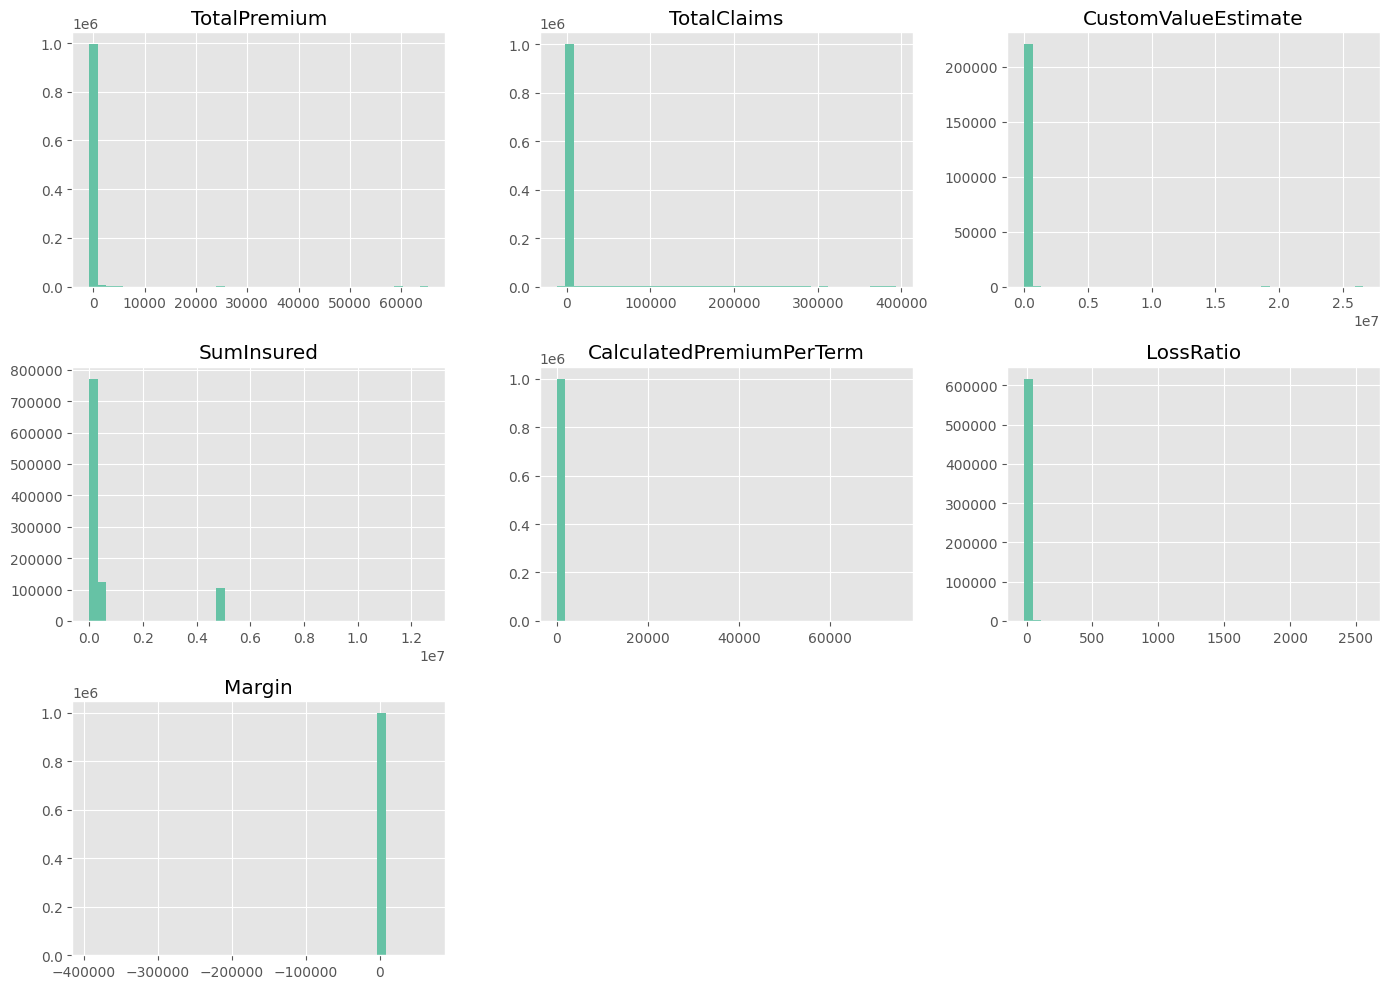

In [23]:
df[financial_cols].hist(
    figsize=(14,10),
    bins=40
)

plt.tight_layout()
plt.show()

Key EDA Findings & Interpretation
Overall Portfolio Performance
The overall portfolio Loss Ratio is 1.048, meaning the insurer pays out approximately R1.05 in claims for every R1.00 collected in premiums.
Since the Loss Ratio is greater than 1, the portfolio appears to be unprofitable overall during the observed period.
This suggests that current pricing strategies may not adequately reflect underlying risk exposure.

Outlier Detection

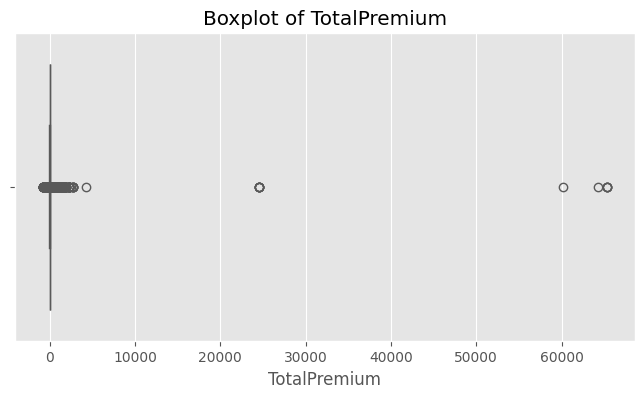

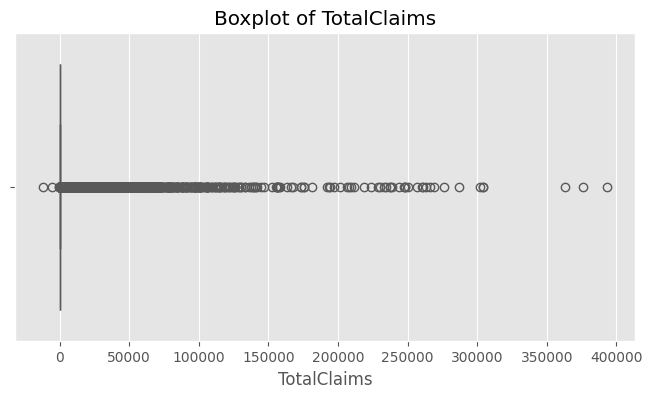

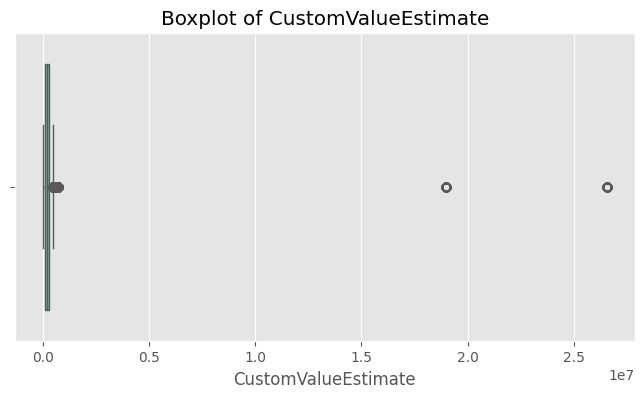

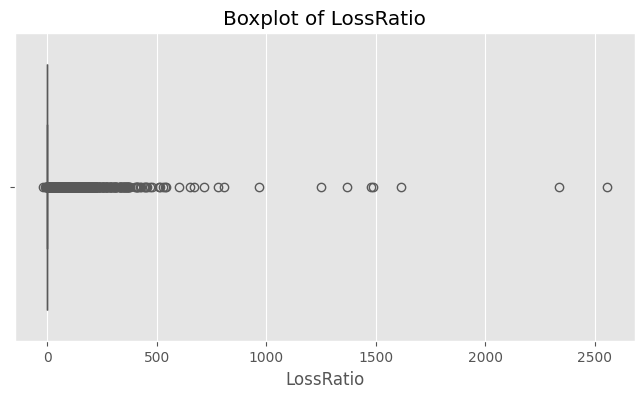

In [24]:
outlier_cols = [
    'TotalPremium',
    'TotalClaims',
    'CustomValueEstimate',
    'LossRatio'
]

for col in outlier_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(
        x=df[col]
    )
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

Loss Ratio by Province

In [25]:
province_lr = df.groupby('Province').apply(
    lambda x: x['TotalClaims'].sum() /
              x['TotalPremium'].sum()
).sort_values(ascending=False)

province_lr

Province
Gauteng          1.222018
KwaZulu-Natal    1.082693
Western Cape     1.059472
North West       0.790367
Mpumalanga       0.720897
Free State       0.680758
Limpopo          0.661199
Eastern Cape     0.633813
Northern Cape    0.282699
dtype: float64

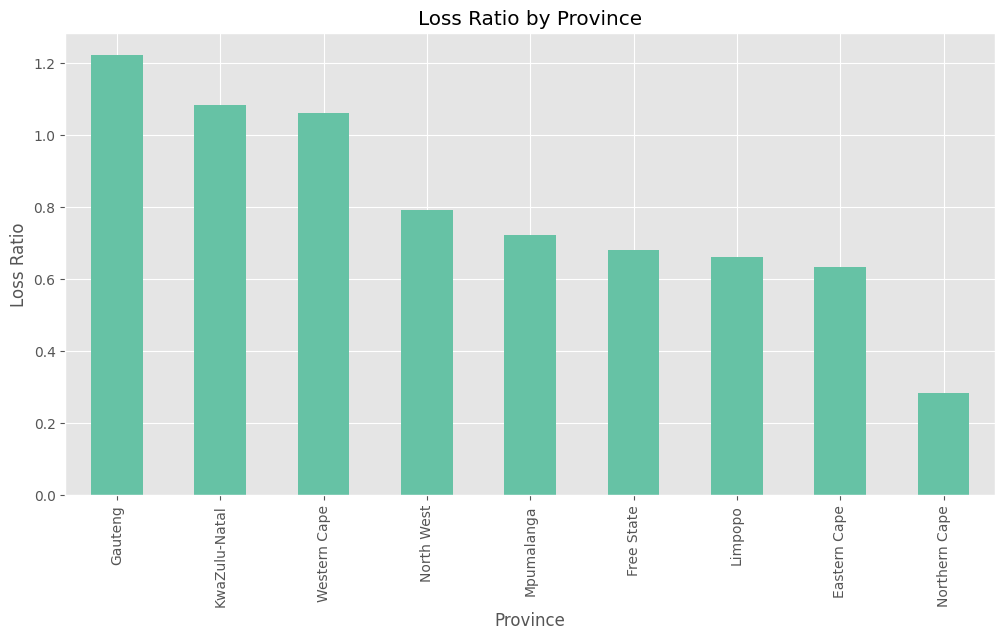

In [26]:
plt.figure(figsize=(12,6))

province_lr.plot(kind='bar')

plt.title("Loss Ratio by Province")

plt.ylabel("Loss Ratio")

plt.show()

Temporal Trends

In [28]:
monthly_trends = df.groupby(
    pd.Grouper(
        key='TransactionMonth',
        freq='ME'
    )
).agg({
    'TotalClaims':'sum',
    'TotalPremium':'sum'
})

monthly_trends['LossRatio'] = (
    monthly_trends['TotalClaims'] /
    monthly_trends['TotalPremium']
)

monthly_trends

,TotalClaims,TotalPremium,LossRatio
TransactionMonth,,,
2013-10-31,0.000000e+00,3.710635e+02,0.000000
2013-11-30,5.058508e+04,2.130747e+04,2.374054
2013-12-31,9.283386e+03,4.248475e+04,0.218511
2014-01-31,1.243686e+04,5.408520e+04,0.229949
2014-02-28,6.298931e+04,6.078844e+04,1.036205
2014-03-31,3.227850e+05,9.857719e+04,3.274439
2014-04-30,3.068636e+05,2.342743e+05,1.309847
2014-05-31,5.180427e+05,3.759117e+05,1.378097
2014-06-30,5.045364e+05,4.862194e+05,1.037672


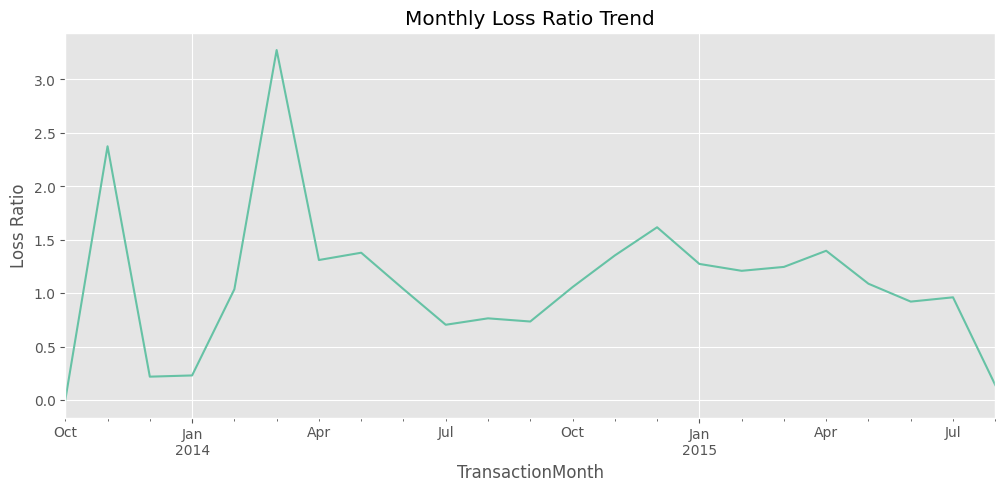

In [29]:
monthly_trends['LossRatio'].plot(
    figsize=(12,5)
)

plt.title("Monthly Loss Ratio Trend")

plt.ylabel("Loss Ratio")

plt.show()

Correlation Matrix

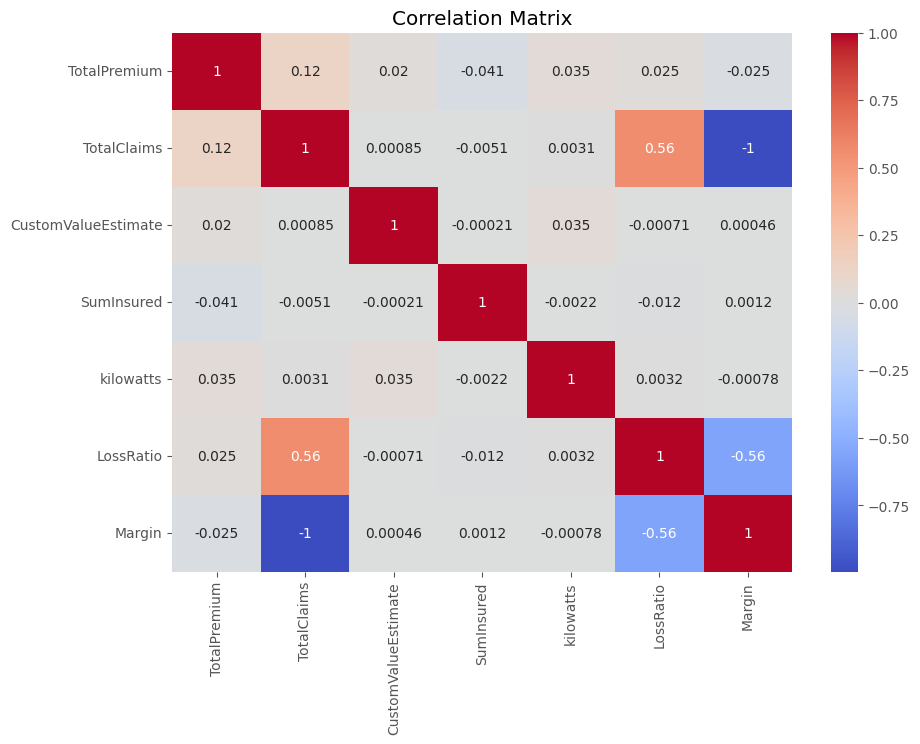

In [30]:
corr_cols = [
    'TotalPremium',
    'TotalClaims',
    'CustomValueEstimate',
    'SumInsured',
    'kilowatts',
    'LossRatio',
    'Margin'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix")

plt.show()